In [1]:
import pandas as pd

In [2]:
docs_df.to_csv('data/cleaned/documents_topics.csv')

NameError: name 'docs_df' is not defined

In [ ]:
topics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1916 entries, 0 to 1915
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Topic                1916 non-null   int64 
 1   Count                1916 non-null   int64 
 2   Name                 1916 non-null   object
 3   Representation       1916 non-null   object
 4   Representative_Docs  1916 non-null   object
dtypes: int64(2), object(3)
memory usage: 75.0+ KB


In [ ]:
topics_df.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,165060,-1_models_spectral_stochastic_optimal,"['models', 'spectral', 'stochastic', 'optimal'...","[""A PDE approach for solving the characteristi..."
1,0,2007,0_reed solomon codes_solomon codes_codes const...,"['reed solomon codes', 'solomon codes', 'codes...",['AG Codes Achieve List-decoding Capacity over...
2,1,1557,1_nonlinear schr odinger_schr odinger equation...,"['nonlinear schr odinger', 'schr odinger equat...","['Decay estimates for nonlinear Schr\\""odinger..."
3,2,1483,2_von neumann algebras_von neumann algebra_neu...,"['von neumann algebras', 'von neumann algebra'...",['The weak tracial Rokhlin property for finite...
4,3,1449,3_partially hyperbolic_topological entropy_uni...,"['partially hyperbolic', 'topological entropy'...",['SRB measures for mostly expanding partially ...
5,4,1371,4_enriched categories_infty categories_monoida...,"['enriched categories', 'infty categories', 'm...","[""An equivalence between enriched $\\infty$-ca..."
6,5,1366,5_randomized kaczmarz_sparse matrix_krylov sub...,"['randomized kaczmarz', 'sparse matrix', 'kryl...",['Parallelization Strategies for the Randomize...
7,6,1125,6_banach lattices_operators banach spaces_bana...,"['banach lattices', 'operators banach spaces',...",['Unbounded continuous operators and unbounded...
8,7,1085,7_coloring graphs_edge colorings_vertex colori...,"['coloring graphs', 'edge colorings', 'vertex ...",['New bounds on the anti-Ramsey numbers of sta...
9,8,1025,8_elliptic equations_laplacian_normalized solu...,"['elliptic equations', 'laplacian', 'normalize...","['Positive normalized solutions of Schr\\""{o}d..."


In [ ]:
import json
import pandas as pd

# --- Step 1: Load the JSON file into a Python dictionary ---
# This step is the same as before.
try:
    with open('results/topics/topic_keywords_20250630_151939.json', 'r') as f:
        keywords_dict = json.load(f)
    print("Successfully loaded topic_keywords.json")
except FileNotFoundError:
    print("Error: topic_keywords.json not found. Please check the path.")
    # Create a dummy dictionary to allow the rest of the script to run for demonstration
    keywords_dict = {
        "0": [["group theory", 0.85], ["finite groups", 0.76]],
        "1": [["differential geometry", 0.91], ["riemannian manifolds", 0.82]]
    }

# --- Step 2: Process the dictionary into the desired DataFrame structure ---

# We will create a list of records (dictionaries), which is an efficient way to build a DataFrame.
records = []
for topic_id, keywords_with_scores in keywords_dict.items():
    # The keywords_with_scores is already a list of lists, which is close to a list of tuples.
    # We can convert it to a list of tuples for consistency, though it's not strictly necessary.
    keyword_tuples = [tuple(item) for item in keywords_with_scores]
    
    records.append({
        'topic': int(topic_id),
        'keywords': keyword_tuples  # Assign the list of tuples directly
    })

# Create the DataFrame from our list of records
keywords_df = pd.DataFrame(records)

# --- Step 3: Verify the result ---

print("\nDataFrame Info:")
keywords_df.info()

print("\nFirst 5 rows of the new DataFrame:")
print(keywords_df.head())

# Let's inspect the data type of the 'keywords' column and an example cell
print(f"\nType of the 'keywords' column: {type(keywords_df['keywords'])}")
if not keywords_df.empty:
    print(f"Type of a cell in 'keywords' column: {type(keywords_df.loc[0, 'keywords'])}")
    print(f"Content of first cell: {keywords_df.loc[0, 'keywords']}")

Successfully loaded topic_keywords.json

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915 entries, 0 to 1914
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   topic     1915 non-null   int64 
 1   keywords  1915 non-null   object
dtypes: int64(1), object(1)
memory usage: 30.1+ KB

First 5 rows of the new DataFrame:
   topic                                           keywords
0      0  [(reed solomon codes, 0.6646755337715149), (so...
1      1  [(nonlinear schr odinger, 0.7245205640792847),...
2      2  [(von neumann algebras, 0.6377335786819458), (...
3      3  [(partially hyperbolic, 0.5368204116821289), (...
4      4  [(enriched categories, 0.5784633159637451), (i...

Type of the 'keywords' column: <class 'pandas.core.series.Series'>
Type of a cell in 'keywords' column: <class 'list'>
Content of first cell: [('reed solomon codes', 0.6646755337715149), ('solomon codes', 0.6306332945823669), ('codes con

In [ ]:
topics_df = topics_df[topics_df['Topic'] != -1]

In [ ]:
# --- Step 1: Perform the Merge with Different Key Names ---

# We use 'left_on' and 'right_on' to specify the join keys for each DataFrame.
# We'll again use a 'left' join to ensure we keep all topics from topics_df,
# including the outlier topic (-1) which doesn't have keywords.

merged_topics_df = pd.merge(
    left=topics_df,
    right=keywords_df,
    left_on='Topic',   # Key column in the left DataFrame
    right_on='topic',  # Key column in the right DataFrame
    how='left'         # Keep all rows from the left DataFrame
)

# --- Step 2: Clean Up and Verify the Result ---

# The merge operation will leave both 'Topic' and 'topic' columns in the result.
# We should drop the redundant 'topic' column from the right DataFrame.
merged_topics_df = merged_topics_df.drop(columns=['topic'])

# Verify the final DataFrame
print("Merge complete. Here is the info for the new DataFrame:")
merged_topics_df.info()

Merge complete. Here is the info for the new DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915 entries, 0 to 1914
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Topic                1915 non-null   int64 
 1   Count                1915 non-null   int64 
 2   Name                 1915 non-null   object
 3   Representation       1915 non-null   object
 4   Representative_Docs  1915 non-null   object
 5   keywords             1915 non-null   object
dtypes: int64(2), object(4)
memory usage: 89.9+ KB


In [ ]:
merged_topics_df = merged_topics_df.rename(columns={'keywords': 'Keywords'})


In [ ]:
merged_topics_df.head(10)

,Topic,Count,Name,Representation,Representative_Docs,Keywords
0,0,2007,0_reed solomon codes_solomon codes_codes const...,"['reed solomon codes', 'solomon codes', 'codes...",['AG Codes Achieve List-decoding Capacity over...,"[(reed solomon codes, 0.6646755337715149), (so..."
1,1,1557,1_nonlinear schr odinger_schr odinger equation...,"['nonlinear schr odinger', 'schr odinger equat...","['Decay estimates for nonlinear Schr\\""odinger...","[(nonlinear schr odinger, 0.7245205640792847),..."
2,2,1483,2_von neumann algebras_von neumann algebra_neu...,"['von neumann algebras', 'von neumann algebra'...",['The weak tracial Rokhlin property for finite...,"[(von neumann algebras, 0.6377335786819458), (..."
3,3,1449,3_partially hyperbolic_topological entropy_uni...,"['partially hyperbolic', 'topological entropy'...",['SRB measures for mostly expanding partially ...,"[(partially hyperbolic, 0.5368204116821289), (..."
4,4,1371,4_enriched categories_infty categories_monoida...,"['enriched categories', 'infty categories', 'm...","[""An equivalence between enriched $\\infty$-ca...","[(enriched categories, 0.5784633159637451), (i..."
5,5,1366,5_randomized kaczmarz_sparse matrix_krylov sub...,"['randomized kaczmarz', 'sparse matrix', 'kryl...",['Parallelization Strategies for the Randomize...,"[(randomized kaczmarz, 0.5546283721923828), (s..."
6,6,1125,6_banach lattices_operators banach spaces_bana...,"['banach lattices', 'operators banach spaces',...",['Unbounded continuous operators and unbounded...,"[(banach lattices, 0.7167437672615051), (opera..."
7,7,1085,7_coloring graphs_edge colorings_vertex colori...,"['coloring graphs', 'edge colorings', 'vertex ...",['New bounds on the anti-Ramsey numbers of sta...,"[(coloring graphs, 0.7209494113922119), (edge ..."
8,8,1025,8_elliptic equations_laplacian_normalized solu...,"['elliptic equations', 'laplacian', 'normalize...","['Positive normalized solutions of Schr\\""{o}d...","[(elliptic equations, 0.4259313642978668), (la..."
9,9,1016,9_singular integral operators_maximal operator...,"['singular integral operators', 'maximal opera...",['Extrapolation for multilinear compact operat...,"[(singular integral operators, 0.5150975584983..."


In [ ]:
merged_topics_df.to_csv('data/cleaned/topic_info.csv')

In [ ]:
topics_classification_df = pd.read_csv('results/collaboration_analysis/topic_classifications_20250630_154254.csv')
topics_classification_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   topic_id                     766 non-null    int64  
 1   total_papers                 766 non-null    int64  
 2   collaboration_papers         766 non-null    int64  
 3   collaboration_rate           766 non-null    float64
 4   repeated_collaboration_rate  766 non-null    float64
 5   degree_centralization        766 non-null    float64
 6   degree_assortativity         763 non-null    float64
 7   modularity                   766 non-null    float64
 8   small_world_coefficient      766 non-null    float64
 9   coreness_ratio               766 non-null    float64
 10  robustness_ratio             766 non-null    float64
 11  avg_constraint               765 non-null    float64
 12  avg_effective_size           765 non-null    float64
 13  group               

---

In [ ]:
docs_df = pd.read_csv('results/topics/document_topics_20250914_174642.csv',low_memory=False)

In [ ]:
all_df['update_date'] = pd.to_datetime(all_df['update_date'])

In [ ]:
docs_df['published_date'] = pd.to_datetime(docs_df['published_date'])

In [ ]:
print(all_df['update_date'].max())
print(docs_df[docs_df['topic'] != -1]['published_date'].max())

2025-05-30 00:00:00
2025-05-30 00:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def analyze_papers_per_topic_distribution(documents_topics_path="results/topics/document_topics_20250914_174642.csv"):
    """
    Analyze the distribution of papers per topic over time to investigate
    the publication drop-off phenomenon.
    
    Parameters:
    - documents_topics_path: Path to your document_topics CSV file
    """
    
    print("="*80)
    print("PAPERS PER TOPIC DISTRIBUTION ANALYSIS")
    print("="*80)
    
    # Load documents_topics data
    try:
        df = pd.read_csv(documents_topics_path)
        print(f"✓ Loaded {len(df):,} papers from {documents_topics_path}")
    except FileNotFoundError:
        print(f"❌ File not found: {documents_topics_path}")
        return
    
    # Examine data structure  
    print(f"\n📊 DATA OVERVIEW:")
    print(f"Columns: {list(df.columns)}")
    print(f"Date range: {df['published_date'].min()} - {df['published_date'].max()}")
    print(f"Unique topics: {df['topic'].nunique():,}")
    print(f"Papers with topic -1 (outliers): {len(df[df['topic'] == -1]):,}")
    
    # Remove outlier topic (-1)
    df_clean = df[df['topic'] != -1].copy()
    print(f"Papers after removing outliers: {len(df_clean):,}")
    print(f"Valid topics: {df_clean['topic'].nunique():,}")
    
    # Create temporal columns
    df_clean['published_date'] = pd.to_datetime(df_clean['published_date'])
    df_clean['year'] = df_clean['published_date'].dt.year
    df_clean['quarter'] = df_clean['published_date'].dt.quarter
    df_clean['year_quarter'] = df_clean['year'].astype(str) + 'Q' + df_clean['quarter'].astype(str)
    
    # 1. Overall topic size distribution
    print(f"\n📈 TOPIC SIZE DISTRIBUTION:")
    topic_sizes = df_clean['topic'].value_counts().sort_values(ascending=False)
    
    print(f"Total topics: {len(topic_sizes):,}")
    print(f"Papers per topic statistics:")
    print(f"  Mean: {topic_sizes.mean():.1f}")
    print(f"  Median: {topic_sizes.median():.1f}")
    print(f"  Std: {topic_sizes.std():.1f}")
    print(f"  Min: {topic_sizes.min()}")
    print(f"  Max: {topic_sizes.max()}")
    
    # Topic size percentiles
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    print(f"\nTopic size percentiles:")
    for p in percentiles:
        print(f"  {p:2d}th percentile: {np.percentile(topic_sizes, p):.0f} papers")
    
    # 2. Topic creation over time
    print(f"\n📅 TEMPORAL ANALYSIS:")
    
    # Find first appearance of each topic
    topic_birth = df_clean.groupby('topic')['year_quarter'].min().reset_index()
    topic_birth_counts = topic_birth['year_quarter'].value_counts().sort_index()
    
    print(f"New topics created per quarter (last 10):")
    for quarter, count in topic_birth_counts.tail(10).items():
        print(f"  {quarter}: {count} new topics")
    
    # Papers per quarter analysis
    quarterly_stats = df_clean.groupby('year_quarter').agg({
        'topic': ['count', 'nunique'],
        'id': 'count'
    }).round(2)
    
    quarterly_stats.columns = ['total_papers', 'unique_topics', 'total_papers_check']
    quarterly_stats['avg_papers_per_topic'] = quarterly_stats['total_papers'] / quarterly_stats['unique_topics']
    
    print(f"\nQuarterly statistics (last 8 quarters):")
    print(quarterly_stats.tail(8)[['total_papers', 'unique_topics', 'avg_papers_per_topic']])
    
    # Check for the specific drop-off pattern you observed
    print(f"\n🚨 INVESTIGATING THE DROP-OFF:")
    recent_quarters = sorted(df_clean['year_quarter'].unique())[-8:]
    
    for i, quarter in enumerate(recent_quarters):
        quarter_data = quarterly_stats.loc[quarter]
        if i > 0:
            prev_quarter = recent_quarters[i-1] 
            prev_data = quarterly_stats.loc[prev_quarter]
            change = ((quarter_data['avg_papers_per_topic'] / prev_data['avg_papers_per_topic']) - 1) * 100
            print(f"{quarter}: {quarter_data['avg_papers_per_topic']:.2f} avg papers/topic (change: {change:+.1f}%)")
        else:
            print(f"{quarter}: {quarter_data['avg_papers_per_topic']:.2f} avg papers/topic (baseline)")
            
    # 3. Topic fragmentation analysis
    print(f"\n🔍 TOPIC FRAGMENTATION ANALYSIS:")
    
    # Calculate topic sizes by quarter for active topics
    topic_quarterly = df_clean.groupby(['year_quarter', 'topic']).size().reset_index(name='papers_in_quarter')
    
    # Find topics that were active in multiple quarters
    topic_activity = topic_quarterly.groupby('topic')['year_quarter'].nunique()
    persistent_topics = topic_activity[topic_activity >= 4].index  # Topics active in 4+ quarters
    
    print(f"Topics active in 4+ quarters: {len(persistent_topics):,}")
    print(f"Topics active in only 1 quarter: {len(topic_activity[topic_activity == 1]):,}")
    
    # Analyze recent quarter patterns
    recent_quarters = sorted(df_clean['year_quarter'].unique())[-8:]  # Last 8 quarters
    
    for quarter in recent_quarters[-4:]:  # Last 4 quarters
        quarter_data = df_clean[df_clean['year_quarter'] == quarter]
        topic_sizes_q = quarter_data['topic'].value_counts()
        
        small_topics = len(topic_sizes_q[topic_sizes_q <= 2])  # Very small topics
        total_topics = len(topic_sizes_q)
        
        print(f"{quarter}: {total_topics:,} topics, {small_topics:,} with ≤2 papers ({small_topics/total_topics*100:.1f}%)")
    
    # 4. Potential issues diagnosis
    print(f"\n🔬 POTENTIAL ISSUES DIAGNOSIS:")
    
    # Check for topic proliferation
    recent_q = recent_quarters[-1]
    old_q = recent_quarters[0]
    
    recent_topics = set(df_clean[df_clean['year_quarter'] == recent_q]['topic'].unique())
    old_topics = set(df_clean[df_clean['year_quarter'] == old_q]['topic'].unique())
    
    new_topics = recent_topics - old_topics
    disappeared_topics = old_topics - recent_topics
    
    print(f"Comparing {old_q} vs {recent_q}:")
    print(f"  New topics appeared: {len(new_topics):,}")
    print(f"  Topics disappeared: {len(disappeared_topics):,}")
    print(f"  Topic overlap: {len(recent_topics & old_topics):,}")
    
    # Check for extremely small topics
    very_small_topics = topic_sizes[topic_sizes <= 5]
    print(f"\nVery small topics (≤5 papers): {len(very_small_topics):,} ({len(very_small_topics)/len(topic_sizes)*100:.1f}%)")
    
    if len(very_small_topics) > len(topic_sizes) * 0.5:
        print("⚠️  WARNING: High proportion of very small topics suggests possible over-fragmentation")
    
    # Investigate the drop-off: compare peak to recent
    peak_quarter_idx = quarterly_stats['avg_papers_per_topic'].idxmax()
    recent_quarter_idx = quarterly_stats.index[-1]
    
    peak_avg = quarterly_stats.loc[peak_quarter_idx, 'avg_papers_per_topic']
    recent_avg = quarterly_stats.loc[recent_quarter_idx, 'avg_papers_per_topic']
    drop_percent = ((recent_avg / peak_avg) - 1) * 100
    
    print(f"\n📉 DROP-OFF ANALYSIS:")
    print(f"Peak quarter: {peak_quarter_idx} with {peak_avg:.2f} avg papers/topic")
    print(f"Recent quarter: {recent_quarter_idx} with {recent_avg:.2f} avg papers/topic")
    print(f"Drop from peak: {drop_percent:.1f}%")
    
    # 5. Create visualizations
    create_distribution_plots(topic_sizes, df_clean)
    
    return {
        'topic_sizes': topic_sizes,
        'quarterly_stats': quarterly_stats,
        'df_clean': df_clean,
        'topic_birth_counts': topic_birth_counts,
        'topic_activity': topic_activity
    }

def create_distribution_plots(topic_sizes, df_clean):
    """Create visualization plots for topic distribution analysis."""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Papers Per Topic Distribution Analysis', fontsize=16, fontweight='bold')
    
    # 1. Topic size histogram (log scale)
    axes[0,0].hist(topic_sizes, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].set_xlabel('Papers per Topic')
    axes[0,0].set_ylabel('Number of Topics')
    axes[0,0].set_title('Distribution of Topic Sizes')
    axes[0,0].set_yscale('log')
    
    # 2. Cumulative distribution
    sorted_sizes = np.sort(topic_sizes)[::-1]
    cumulative_papers = np.cumsum(sorted_sizes)
    axes[0,1].plot(range(1, len(sorted_sizes)+1), cumulative_papers, 'b-', linewidth=2)
    axes[0,1].set_xlabel('Topic Rank')
    axes[0,1].set_ylabel('Cumulative Papers')
    axes[0,1].set_title('Cumulative Papers by Topic Rank')
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Topic size vs rank (power law check)
    axes[1,0].loglog(range(1, len(sorted_sizes)+1), sorted_sizes, 'ro', alpha=0.6, markersize=3)
    axes[1,0].set_xlabel('Topic Rank (log)')
    axes[1,0].set_ylabel('Papers per Topic (log)')
    axes[1,0].set_title('Topic Size vs Rank (Log-Log)')
    axes[1,0].grid(True, alpha=0.3)
    
    # 4. Temporal trend
    quarterly_topics = df_clean.groupby('year_quarter')['topic'].nunique()
    quarterly_papers = df_clean.groupby('year_quarter').size()
    quarterly_avg = quarterly_papers / quarterly_topics
    
    axes[1,1].plot(range(len(quarterly_avg)), quarterly_avg.values, 'g-o', linewidth=2, markersize=6)
    axes[1,1].set_xlabel('Quarter Index')
    axes[1,1].set_ylabel('Avg Papers per Topic')
    axes[1,1].set_title('Average Papers per Topic Over Time')
    axes[1,1].grid(True, alpha=0.3)
    
    # Add quarter labels for recent periods
    quarter_labels = quarterly_avg.index[-8:]  # Last 8 quarters
    label_positions = range(len(quarterly_avg)-8, len(quarterly_avg))
    if len(quarter_labels) > 0:
        axes[1,1].set_xticks(label_positions[::2])  # Every other label
        axes[1,1].set_xticklabels(quarter_labels[::2], rotation=45)
    
    # Highlight the drop-off
    peak_idx = np.argmax(quarterly_avg.values)
    axes[1,1].axvline(x=peak_idx, color='red', linestyle='--', alpha=0.7, label=f'Peak: {quarterly_avg.index[peak_idx]}')
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.show()


PAPERS PER TOPIC DISTRIBUTION ANALYSIS
✓ Loaded 655,976 papers from results/topics/document_topics_20250914_174642.csv

📊 DATA OVERVIEW:
Columns: ['id', 'title', 'topic', 'published_date', 'primary_category']
Date range: 2020-01-01 - 2025-05-30
Unique topics: 3,047
Papers with topic -1 (outliers): 342,733
Papers after removing outliers: 313,243
Valid topics: 3,046

📈 TOPIC SIZE DISTRIBUTION:
Total topics: 3,046
Papers per topic statistics:
  Mean: 102.8
  Median: 47.0
  Std: 237.5
  Min: 20
  Max: 6902

Topic size percentiles:
  10th percentile: 22 papers
  25th percentile: 29 papers
  50th percentile: 47 papers
  75th percentile: 96 papers
  90th percentile: 209 papers
  95th percentile: 340 papers
  99th percentile: 839 papers

📅 TEMPORAL ANALYSIS:
New topics created per quarter (last 10):
  2022Q2: 16 new topics
  2022Q3: 8 new topics
  2022Q4: 8 new topics
  2023Q1: 13 new topics
  2023Q2: 17 new topics
  2023Q3: 9 new topics
  2023Q4: 11 new topics
  2024Q1: 2 new topics
  2024Q2:

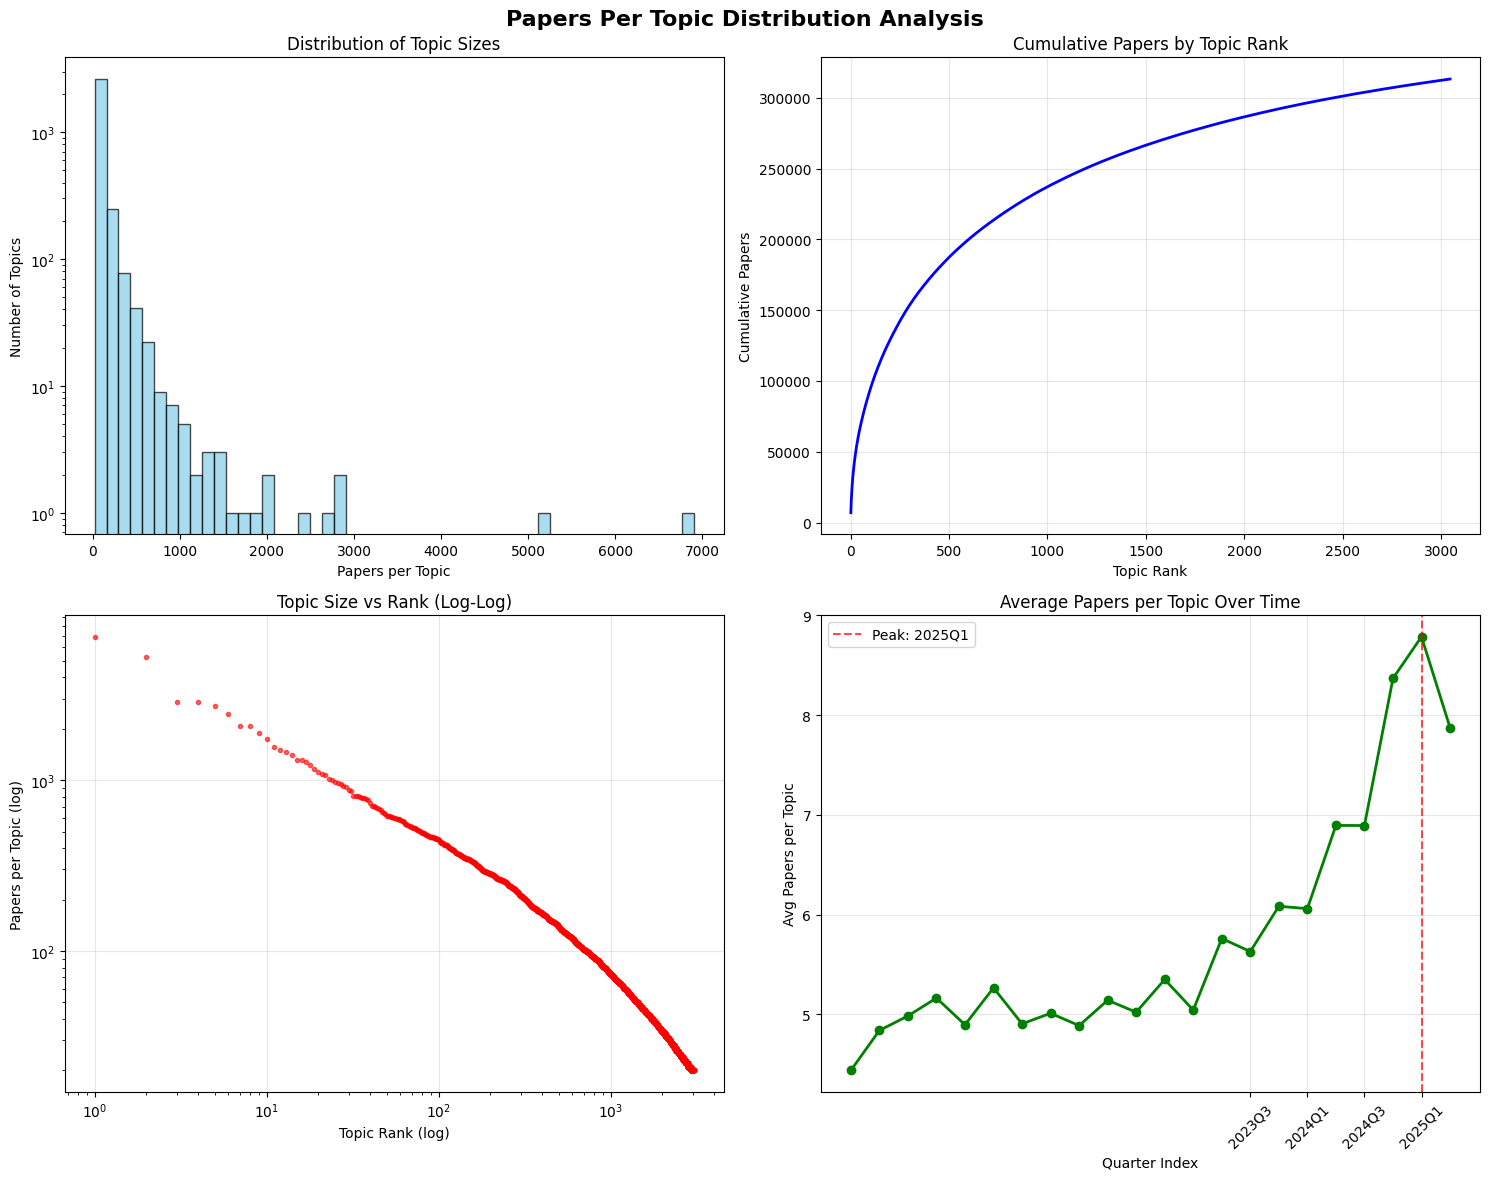

{'topic_sizes': topic
 0       6902
 1       5226
 2       2883
 3       2854
 4       2699
         ... 
 3012      20
 2951      20
 2943      20
 2958      20
 3028      20
 Name: count, Length: 3046, dtype: int64,
 'quarterly_stats':               total_papers  unique_topics  total_papers_check  \
 year_quarter                                                    
 2020Q1                8765           1975                8765   
 2020Q2               10331           2135               10331   
 2020Q3               10691           2145               10691   
 2020Q4               11200           2169               11200   
 2021Q1               10937           2234               10937   
 2021Q2               12175           2312               12175   
 2021Q3               11399           2324               11399   
 2021Q4               11585           2312               11585   
 2022Q1               11529           2359               11529   
 2022Q2               12067          

In [ ]:
analyze_papers_per_topic_distribution()

In [ ]:
import pandas as pd

In [ ]:
topics_df = pd.read_csv('data/cleaned/cs_topics_info.csv',low_memory=False)
topics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3046 entries, 0 to 3045
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Topic           3046 non-null   int64 
 1   Count           3046 non-null   int64 
 2   Representation  3046 non-null   object
 3   Classification  3046 non-null   object
 4   is_llm_related  3046 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 119.1+ KB


In [ ]:
topic_metrics = pd.read_csv('data/cleaned/topic_period_metrics.csv',low_memory=False)
topic_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6025 entries, 0 to 6024
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   modularity        6025 non-null   float64
 1   coreness_ratio    6025 non-null   float64
 2   size              6025 non-null   int64  
 3   density           6025 non-null   float64
 4   topic_id          6025 non-null   int64  
 5   period            6025 non-null   object 
 6   Classification    6025 non-null   object 
 7   papers_in_period  6025 non-null   int64  
 8   group             6025 non-null   object 
dtypes: float64(3), int64(3), object(3)
memory usage: 423.8+ KB


In [ ]:
topic_metrics.head(20)

,modularity,coreness_ratio,size,density,topic_id,period,Classification,papers_in_period,group
0,0.913487,0.012055,3318,0.002130,0,pre,CONTROL,3193,control
1,0.922513,0.006665,4201,0.001699,0,post,CONTROL,3661,control
2,0.813844,0.034157,1903,0.003331,1,pre,CONTROL,2417,control
3,0.802800,0.006531,2450,0.002716,1,post,CONTROL,2782,control
4,0.916422,0.017518,685,0.005861,2,pre,CONTROL,1343,control
5,0.903242,0.016932,1004,0.004099,2,post,CONTROL,1531,control
6,0.866516,0.015119,1852,0.004643,3,pre,LLM_RELATED,1105,treat
7,0.818310,0.007922,3282,0.003355,3,post,LLM_RELATED,1717,treat
8,0.827393,0.010717,1493,0.005122,4,pre,CONTROL,1232,control
9,0.883474,0.008089,1978,0.003588,4,post,CONTROL,1438,control


In [ ]:
treat_pre_topic_metrics = topic_metrics[(topic_metrics['period'] == 'pre') & (topic_metrics['group'] == 'treat')]
treat_post_topic_metrics = topic_metrics[(topic_metrics['period'] == 'post') & (topic_metrics['group'] == 'treat')]
control_pre_topic_metrics = topic_metrics[(topic_metrics['period'] == 'pre') & (topic_metrics['group'] == 'control')]
control_post_topic_metrics = topic_metrics[(topic_metrics['period'] == 'post') & (topic_metrics['group'] == 'control')]

In [ ]:
treat_pre_metric_values = treat_pre_topic_metrics.groupby(['period','group'])[['modularity','coreness_ratio']].mean()
treat_post_metric_values = treat_post_topic_metrics.groupby(['period','group'])[['modularity','coreness_ratio']].mean()
control_pre_metric_values = control_pre_topic_metrics.groupby(['period','group'])[['modularity','coreness_ratio']].mean()
control_post_metric_values = control_post_topic_metrics.groupby(['period','group'])[['modularity','coreness_ratio']].mean()


In [ ]:
print(treat_pre_metric_values)

              modularity  coreness_ratio
period group                            
pre    treat    0.172296        0.739341


In [ ]:
print(treat_post_metric_values)

              modularity  coreness_ratio
period group                            
post   treat    0.258446        0.622645


In [ ]:
print(control_pre_metric_values)

                modularity  coreness_ratio
period group                              
pre    control    0.194903        0.708684


In [ ]:
print(control_post_metric_values)

                modularity  coreness_ratio
period group                              
post   control    0.238945        0.657917


---

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load your data
df = pd.read_csv('data/cleaned/topic_period_metrics.csv')

# Create the four groups
treat_pre = df[(df['group'] == 'treat') & (df['period'] == 'pre')]
treat_post = df[(df['group'] == 'treat') & (df['period'] == 'post')]
control_pre = df[(df['group'] == 'control') & (df['period'] == 'pre')]
control_post = df[(df['group'] == 'control') & (df['period'] == 'post')]

print("="*70)
print("MANUAL DIFFERENCE-IN-DIFFERENCES CALCULATION")
print("="*70)

# Analyze both metrics
for metric in ['modularity', 'coreness_ratio']:
    print(f"\n{'='*70}")
    print(f"METRIC: {metric.upper()}")
    print(f"{'='*70}")
    
    # Calculate means for each group
    treat_pre_mean = treat_pre[metric].mean()
    treat_post_mean = treat_post[metric].mean()
    control_pre_mean = control_pre[metric].mean()
    control_post_mean = control_post[metric].mean()
    
    print(f"\n--- Group Means ---")
    print(f"Treatment Pre:  {treat_pre_mean:.4f} (n={len(treat_pre)})")
    print(f"Treatment Post: {treat_post_mean:.4f} (n={len(treat_post)})")
    print(f"Control Pre:    {control_pre_mean:.4f} (n={len(control_pre)})")
    print(f"Control Post:   {control_post_mean:.4f} (n={len(control_post)})")
    
    # Calculate changes within each group
    treat_change = treat_post_mean - treat_pre_mean
    control_change = control_post_mean - control_pre_mean
    
    print(f"\n--- Within-Group Changes ---")
    print(f"Treatment change (Post - Pre): {treat_change:+.4f}")
    print(f"Control change (Post - Pre):   {control_change:+.4f}")
    
    # Calculate DiD estimator
    did_estimate = treat_change - control_change
    
    print(f"\n--- DiD Estimate ---")
    print(f"DiD = (Treat_Post - Treat_Pre) - (Control_Post - Control_Pre)")
    print(f"DiD = ({treat_post_mean:.4f} - {treat_pre_mean:.4f}) - ({control_post_mean:.4f} - {control_pre_mean:.4f})")
    print(f"DiD = {treat_change:.4f} - {control_change:.4f}")
    print(f"DiD = {did_estimate:+.4f}")
    
    # Calculate percent change from baseline
    baseline = treat_pre_mean
    percent_change = (did_estimate / baseline) * 100 if baseline != 0 else 0
    print(f"Percent change from treatment baseline: {percent_change:+.1f}%")
    
    # Simple t-test for significance (not accounting for clustering)
    # This is a rough approximation - proper DiD would use regression with clustered SE
    treat_diff = treat_post[metric].values - treat_pre[metric].values
    control_diff = control_post[metric].values - control_pre[metric].values
    
    # For topics that appear in both periods, calculate difference
    # This is simplified - proper analysis would match topics
    print(f"\n--- Statistical Significance (Approximate) ---")
    print("Note: This uses simple t-test, not proper DiD regression")
    
    # Two-sample t-test on the changes
    if len(treat_diff) > 0 and len(control_diff) > 0:
        t_stat, p_value = stats.ttest_ind(treat_diff, control_diff)
        print(f"t-statistic: {t_stat:.3f}")
        print(f"p-value: {p_value:.4f}")
        sig = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.1 else "ns"
        print(f"Significance: {sig}")

print("\n" + "="*70)
print("INTERPRETATION NOTES")
print("="*70)
print("""
1. The DiD estimate shows the treatment effect after accounting for 
   time trends that affected both groups.

2. Positive DiD = Treatment group increased more (or decreased less)
   Negative DiD = Treatment group decreased more (or increased less)

3. This manual calculation matches what regression-based DiD estimates,
   but regression allows for:
   - Controlling for covariates
   - Proper standard errors with clustering
   - Topic and period fixed effects

4. If baseline values look wrong (e.g., very low modularity), the problem
   is in your data pipeline, not the DiD methodology.
""")

MANUAL DIFFERENCE-IN-DIFFERENCES CALCULATION

METRIC: MODULARITY

--- Group Means ---
Treatment Pre:  0.1723 (n=522)
Treatment Post: 0.2584 (n=545)
Control Pre:    0.1949 (n=2459)
Control Post:   0.2389 (n=2499)

--- Within-Group Changes ---
Treatment change (Post - Pre): +0.0861
Control change (Post - Pre):   +0.0440

--- DiD Estimate ---
DiD = (Treat_Post - Treat_Pre) - (Control_Post - Control_Pre)
DiD = (0.2584 - 0.1723) - (0.2389 - 0.1949)
DiD = 0.0861 - 0.0440
DiD = +0.0421
Percent change from treatment baseline: +24.4%


ValueError: operands could not be broadcast together with shapes (545,) (522,) 

In [ ]:
import pandas as pd
import numpy as np

# Load both datasets
period_metrics = pd.read_csv('data/cleaned/topic_period_metrics.csv')
topic_info = pd.read_csv('data/cleaned/cs_topics_info.csv')

# Merge to get total topic sizes
# Use only pre-period for baseline analysis
pre_period = period_metrics[period_metrics['period'] == 'pre'].copy()
merged = pre_period.merge(topic_info[['Topic', 'Count']], 
                          left_on='topic_id', right_on='Topic', how='left')

print("="*70)
print("TOPIC SIZE vs MODULARITY ANALYSIS")
print("="*70)

print(f"\nTotal topics in analysis: {len(merged)}")
print(f"Topics with size data: {merged['Count'].notna().sum()}")

# Calculate percentiles by topic size
percentiles = [0, 20, 40, 60, 80, 100]
merged['size_percentile'] = pd.qcut(merged['Count'], q=5, labels=[1,2,3,4,5], duplicates='drop')

print("\n" + "="*70)
print("MODULARITY BY TOPIC SIZE QUINTILE")
print("="*70)

for quintile in [1, 2, 3, 4, 5]:
    subset = merged[merged['size_percentile'] == quintile]
    if len(subset) > 0:
        print(f"\nQuintile {quintile} ({'Bottom 20%' if quintile==1 else 'Top 20%' if quintile==5 else f'{(quintile-1)*20}-{quintile*20}%'}):")
        print(f"  N topics: {len(subset)}")
        print(f"  Paper count range: {subset['Count'].min():.0f} - {subset['Count'].max():.0f}")
        print(f"  Network size range: {subset['size'].min():.0f} - {subset['size'].max():.0f}")
        print(f"  Mean modularity: {subset['modularity'].mean():.3f}")
        print(f"  Median modularity: {subset['modularity'].median():.3f}")
        print(f"  Std modularity: {subset['modularity'].std():.3f}")

# Compare top 20% and bottom 20% to cross-sectional findings
print("\n" + "="*70)
print("COMPARISON WITH CROSS-SECTIONAL STUDY")
print("="*70)

bottom_20 = merged[merged['size_percentile'] == 1]
top_20 = merged[merged['size_percentile'] == 5]

print("\nBOTTOM 20% (Niche topics):")
print(f"  DiD baseline modularity: {bottom_20['modularity'].mean():.3f}")
print(f"  Cross-sectional niche modularity: 0.688")
print(f"  Difference: {bottom_20['modularity'].mean() - 0.688:.3f}")

print("\nTOP 20% (Popular topics):")
print(f"  DiD baseline modularity: {top_20['modularity'].mean():.3f}")
print(f"  Cross-sectional popular modularity: 0.879")
print(f"  Difference: {top_20['modularity'].mean() - 0.879:.3f}")

print("\nMIDDLE 60% (Excluded from cross-sectional):")
middle_60 = merged[merged['size_percentile'].isin([2, 3, 4])]
print(f"  DiD baseline modularity: {middle_60['modularity'].mean():.3f}")
print(f"  N topics: {len(middle_60)}")
print(f"  This group was EXCLUDED from cross-sectional analysis")

print("\n" + "="*70)
print("OVERALL DISTRIBUTION")
print("="*70)
print(f"\nAll topics mean modularity: {merged['modularity'].mean():.3f}")
print(f"All topics median modularity: {merged['modularity'].median():.3f}")

print("\nWeighted by group composition in DiD:")
treat = merged[merged['group'] == 'treat']
control = merged[merged['group'] == 'control']
print(f"Treatment topics mean: {treat['modularity'].mean():.3f}")
print(f"Control topics mean: {control['modularity'].mean():.3f}")

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("""
If the top 20% have modularity ~0.7-0.9 and bottom 20% have ~0.6-0.8,
while middle 60% have ~0.1-0.3, then:

1. Your DiD baseline of 0.17-0.19 is correct for the full distribution
2. Your cross-sectional findings of 0.68-0.88 represent only extremes
3. The discrepancy is due to sample selection, not data errors
4. Your DiD analysis is methodologically sound

If ALL size ranges show low modularity (~0.2), then there's still
a fundamental difference between temporal vs full network construction.
""")

TOPIC SIZE vs MODULARITY ANALYSIS

Total topics in analysis: 2981
Topics with size data: 2981

MODULARITY BY TOPIC SIZE QUINTILE

Quintile 1 (Bottom 20%):
  N topics: 625
  Paper count range: 20 - 26
  Network size range: 2 - 344
  Mean modularity: 0.072
  Median modularity: 0.000
  Std modularity: 0.116

Quintile 2 (20-40%):
  N topics: 576
  Paper count range: 27 - 38
  Network size range: 2 - 361
  Mean modularity: 0.096
  Median modularity: 0.003
  Std modularity: 0.131

Quintile 3 (40-60%):
  N topics: 591
  Paper count range: 39 - 60
  Network size range: 3 - 565
  Mean modularity: 0.152
  Median modularity: 0.120
  Std modularity: 0.155

Quintile 4 (60-80%):
  N topics: 596
  Paper count range: 61 - 118
  Network size range: 3 - 836
  Mean modularity: 0.228
  Median modularity: 0.221
  Std modularity: 0.184

Quintile 5 (Top 20%):
  N topics: 593
  Paper count range: 119 - 6902
  Network size range: 2 - 3318
  Mean modularity: 0.410
  Median modularity: 0.431
  Std modularity: 0.

In [ ]:
import pandas as pd
import numpy as np

# Load your data
df = pd.read_csv('data/cleaned/topic_period_metrics.csv')

# Create the four groups
treat_pre = df[(df['group'] == 'treat') & (df['period'] == 'pre')]
treat_post = df[(df['group'] == 'treat') & (df['period'] == 'post')]
control_pre = df[(df['group'] == 'control') & (df['period'] == 'pre')]
control_post = df[(df['group'] == 'control') & (df['period'] == 'post')]

print("="*70)
print("DIFFERENCE-IN-DIFFERENCES EFFECT SIZES")
print("="*70)

for metric in ['modularity', 'coreness_ratio']:
    print(f"\n{'='*70}")
    print(f"METRIC: {metric.upper()}")
    print(f"{'='*70}")
    
    # Calculate group means
    treat_pre_mean = treat_pre[metric].mean()
    treat_post_mean = treat_post[metric].mean()
    control_pre_mean = control_pre[metric].mean()
    control_post_mean = control_post[metric].mean()
    
    # Calculate DiD estimate
    treat_change = treat_post_mean - treat_pre_mean
    control_change = control_post_mean - control_pre_mean
    did_estimate = treat_change - control_change
    
    print(f"\nDiD Estimate: {did_estimate:+.4f}")
    
    # EFFECT SIZE 1: Percent change from treatment baseline
    baseline = treat_pre_mean
    percent_change = (did_estimate / baseline) * 100 if baseline != 0 else 0
    print(f"\n1. PERCENT CHANGE FROM TREATMENT BASELINE")
    print(f"   Treatment baseline: {baseline:.4f}")
    print(f"   DiD effect / baseline: {percent_change:+.1f}%")
    
    # EFFECT SIZE 2: Cohen's d (standardized mean difference)
    # Use pooled standard deviation from all groups
    all_values = pd.concat([
        treat_pre[metric], treat_post[metric],
        control_pre[metric], control_post[metric]
    ])
    pooled_sd = all_values.std()
    cohens_d = did_estimate / pooled_sd
    
    print(f"\n2. COHEN'S D (Standardized Effect)")
    print(f"   Pooled SD: {pooled_sd:.4f}")
    print(f"   Cohen's d: {cohens_d:.3f}")
    
    # Interpret Cohen's d
    if abs(cohens_d) < 0.2:
        interpretation = "negligible"
    elif abs(cohens_d) < 0.5:
        interpretation = "small"
    elif abs(cohens_d) < 0.8:
        interpretation = "medium"
    else:
        interpretation = "large"
    print(f"   Interpretation: {interpretation} effect")
    
    # EFFECT SIZE 3: Relative acceleration
    # How much faster did treatment group change compared to control?
    if control_change != 0:
        acceleration_factor = treat_change / control_change
        print(f"\n3. RELATIVE ACCELERATION")
        print(f"   Treatment change rate: {treat_change:+.4f}")
        print(f"   Control change rate: {control_change:+.4f}")
        print(f"   Acceleration factor: {acceleration_factor:.2f}x")
        print(f"   Interpretation: Treatment group changed {acceleration_factor:.1f}x faster than control")
    
    # EFFECT SIZE 4: Standardized units (effect in baseline SD)
    baseline_sd = treat_pre[metric].std()
    std_units = did_estimate / baseline_sd
    
    print(f"\n4. EFFECT IN BASELINE STANDARD DEVIATIONS")
    print(f"   Treatment pre-period SD: {baseline_sd:.4f}")
    print(f"   DiD effect in SD units: {std_units:+.3f}")
    
    # EFFECT SIZE 5: R-squared contribution (proportion of variance explained)
    # This is approximate - proper R² would come from regression
    total_variance = all_values.var()
    # Between-group variance due to treatment effect (simplified)
    treatment_variance = (did_estimate ** 2) / 4  # Rough approximation
    pseudo_r_squared = treatment_variance / total_variance
    
    print(f"\n5. APPROXIMATE VARIANCE EXPLAINED")
    print(f"   Pseudo R²: {pseudo_r_squared:.4f} ({pseudo_r_squared*100:.2f}%)")

print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)

summary_data = []
for metric in ['modularity', 'coreness_ratio']:
    # Recalculate key metrics
    treat_pre_mean = treat_pre[metric].mean()
    treat_post_mean = treat_post[metric].mean()
    control_pre_mean = control_pre[metric].mean()
    control_post_mean = control_post[metric].mean()
    
    treat_change = treat_post_mean - treat_pre_mean
    control_change = control_post_mean - control_pre_mean
    did_estimate = treat_change - control_change
    
    baseline = treat_pre_mean
    percent_change = (did_estimate / baseline) * 100 if baseline != 0 else 0
    
    all_values = pd.concat([
        treat_pre[metric], treat_post[metric],
        control_pre[metric], control_post[metric]
    ])
    pooled_sd = all_values.std()
    cohens_d = did_estimate / pooled_sd
    
    if abs(cohens_d) < 0.2:
        interpretation = "negligible"
    elif abs(cohens_d) < 0.5:
        interpretation = "small"
    elif abs(cohens_d) < 0.8:
        interpretation = "medium"
    else:
        interpretation = "large"
    
    acceleration = treat_change / control_change if control_change != 0 else np.nan
    
    summary_data.append({
        'Metric': metric,
        'DiD Estimate': f"{did_estimate:+.4f}",
        'Percent Change': f"{percent_change:+.1f}%",
        "Cohen's d": f"{cohens_d:.3f}",
        'Interpretation': interpretation,
        'Acceleration': f"{acceleration:.2f}x"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*70)
print("REPORTING RECOMMENDATIONS")
print("="*70)
print("""
For your paper, report multiple effect sizes:

1. RAW EFFECT: "The ChatGPT shock increased modularity by 0.042 units"
   → Shows absolute magnitude

2. PERCENT CHANGE: "A 24.4% increase from treatment baseline"
   → Contextualizes relative to starting point

3. COHEN'S D: "A small/medium standardized effect (d = X.XX)"
   → Enables comparison across studies and metrics

4. ACCELERATION: "Treatment networks modularized 1.96x faster than controls"
   → Most intuitive interpretation for your research question

Report all four to give readers multiple perspectives on effect magnitude.
The acceleration factor is particularly compelling for causal narratives.
""")

DIFFERENCE-IN-DIFFERENCES EFFECT SIZES

METRIC: MODULARITY

DiD Estimate: +0.0421

1. PERCENT CHANGE FROM TREATMENT BASELINE
   Treatment baseline: 0.1723
   DiD effect / baseline: +24.4%

2. COHEN'S D (Standardized Effect)
   Pooled SD: 0.2190
   Cohen's d: 0.192
   Interpretation: negligible effect

3. RELATIVE ACCELERATION
   Treatment change rate: +0.0861
   Control change rate: +0.0440
   Acceleration factor: 1.96x
   Interpretation: Treatment group changed 2.0x faster than control

4. EFFECT IN BASELINE STANDARD DEVIATIONS
   Treatment pre-period SD: 0.2016
   DiD effect in SD units: +0.209

5. APPROXIMATE VARIANCE EXPLAINED
   Pseudo R²: 0.0092 (0.92%)

METRIC: CORENESS_RATIO

DiD Estimate: -0.0659

1. PERCENT CHANGE FROM TREATMENT BASELINE
   Treatment baseline: 0.7393
   DiD effect / baseline: -8.9%

2. COHEN'S D (Standardized Effect)
   Pooled SD: 0.2896
   Cohen's d: -0.228
   Interpretation: small effect

3. RELATIVE ACCELERATION
   Treatment change rate: -0.1167
   Control

---

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Load data
df = pd.read_csv('data/cleaned/topic_period_metrics.csv')

# Create regression variables
df['treat'] = (df['group'] == 'treat').astype(int)
df['post'] = (df['period'] == 'post').astype(int)
df['treat_post'] = df['treat'] * df['post']
df['log_size'] = np.log(df['size'] + 1)

print("="*70)
print("SIZE-CONTROLLED DiD REGRESSION ANALYSIS")
print("="*70)

for metric in ['modularity', 'coreness_ratio']:
    print(f"\n{'='*70}")
    print(f"METRIC: {metric.upper()}")
    print(f"{'='*70}")
    
    # Model 1: Basic DiD (no controls)
    formula_basic = f"{metric} ~ treat + post + treat_post"
    model_basic = smf.ols(formula_basic, data=df).fit()
    
    did_basic = model_basic.params['treat_post']
    se_basic = model_basic.bse['treat_post']
    p_basic = model_basic.pvalues['treat_post']
    
    print(f"\n--- MODEL 1: BASIC DiD (No Controls) ---")
    print(f"DiD Coefficient: {did_basic:+.4f}")
    print(f"Std Error: {se_basic:.4f}")
    print(f"p-value: {p_basic:.4f}")
    sig = "***" if p_basic < 0.01 else "**" if p_basic < 0.05 else "*" if p_basic < 0.1 else ""
    print(f"Significance: {sig if sig else 'not significant'}")
    
    # Model 2: DiD with size and density controls
    formula_controls = f"{metric} ~ treat + post + treat_post + log_size + density"
    model_controls = smf.ols(formula_controls, data=df).fit()
    
    did_controls = model_controls.params['treat_post']
    se_controls = model_controls.bse['treat_post']
    p_controls = model_controls.pvalues['treat_post']
    
    print(f"\n--- MODEL 2: DiD WITH SIZE CONTROLS ---")
    print(f"DiD Coefficient: {did_controls:+.4f}")
    print(f"Std Error: {se_controls:.4f}")
    print(f"p-value: {p_controls:.4f}")
    sig = "***" if p_controls < 0.01 else "**" if p_controls < 0.05 else "*" if p_controls < 0.1 else ""
    print(f"Significance: {sig if sig else 'not significant'}")
    
    # Compare the two
    attenuation = ((did_basic - did_controls) / did_basic) * 100 if did_basic != 0 else 0
    
    print(f"\n--- COMPARISON ---")
    print(f"Change in coefficient: {did_controls - did_basic:+.4f}")
    print(f"Attenuation: {attenuation:.1f}%")
    
    # Also show the size coefficient
    size_coef = model_controls.params['log_size']
    size_p = model_controls.pvalues['log_size']
    print(f"\nlog(size) coefficient: {size_coef:+.4f} (p={size_p:.4f})")
    
    # Interpretation
    print(f"\n--- INTERPRETATION ---")
    if abs(attenuation) < 30:
        print("✓ Effect PERSISTS after controlling for size")
        print("  → EXOGENOUS structural reorganization")
        print("  → The shock changed collaboration patterns beyond mere growth")
    elif abs(attenuation) > 70:
        print("✗ Effect SUBSTANTIALLY ATTENUATED by size control")
        print("  → ENDOGENOUS growth effect")
        print("  → Structural changes follow mechanically from network expansion")
    else:
        print("~ Effect PARTIALLY ATTENUATED")
        print("  → MIXED mechanism")
        print("  → Both growth (endogenous) and reorganization (exogenous) contribute")

print("\n" + "="*70)
print("OVERALL INTERPRETATION")
print("="*70)
print("""
KEY QUESTION: Does the ChatGPT shock cause:
  A) Genuine structural reorganization (exogenous), OR
  B) Just faster network growth (endogenous)?

If attenuation < 30%: The shock reorganized how people collaborate
If attenuation > 70%: The shock just brought in more people
If 30-70%: Both mechanisms contribute

The size coefficient shows how much structure changes with scale.
If it's large and significant, network growth drives much of the pattern.
""")

SIZE-CONTROLLED DiD REGRESSION ANALYSIS

METRIC: MODULARITY

--- MODEL 1: BASIC DiD (No Controls) ---
DiD Coefficient: +0.0421
Std Error: 0.0147
p-value: 0.0041
Significance: ***

--- MODEL 2: DiD WITH SIZE CONTROLS ---
DiD Coefficient: -0.0100
Std Error: 0.0053
p-value: 0.0583
Significance: *

--- COMPARISON ---
Change in coefficient: -0.0521
Attenuation: 123.8%

log(size) coefficient: +0.0460 (p=0.0000)

--- INTERPRETATION ---
✗ Effect SUBSTANTIALLY ATTENUATED by size control
  → ENDOGENOUS growth effect
  → Structural changes follow mechanically from network expansion

METRIC: CORENESS_RATIO

--- MODEL 1: BASIC DiD (No Controls) ---
DiD Coefficient: -0.0659
Std Error: 0.0194
p-value: 0.0007
Significance: ***

--- MODEL 2: DiD WITH SIZE CONTROLS ---
DiD Coefficient: +0.0016
Std Error: 0.0072
p-value: 0.8211
Significance: not significant

--- COMPARISON ---
Change in coefficient: +0.0676
Attenuation: 102.5%

log(size) coefficient: -0.0373 (p=0.0000)

--- INTERPRETATION ---
✗ Effect SU

---

In [ ]:
metrics_df = pd.read_csv('results/collaboration_analysis/topic_summaries_10metrics_fixed_20250914_201257.csv', low_memory=False)
metrics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3046 entries, 0 to 3045
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   topic_id                     3046 non-null   int64  
 1   total_papers                 3046 non-null   int64  
 2   collaboration_papers         3046 non-null   int64  
 3   collaboration_rate           3046 non-null   float64
 4   repeated_collaboration_rate  3046 non-null   float64
 5   degree_centralization        3046 non-null   float64
 6   degree_assortativity         3046 non-null   float64
 7   modularity                   3046 non-null   float64
 8   small_world_coefficient      3046 non-null   float64
 9   coreness_ratio               3046 non-null   float64
 10  robustness_ratio             3046 non-null   float64
 11  avg_constraint               3043 non-null   float64
 12  avg_effective_size           3043 non-null   float64
dtypes: float64(10), in

In [ ]:
topic_info = pd.read_csv('data/cleaned/cs_topics_info.csv',low_memory=False)
topic_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3046 entries, 0 to 3045
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Topic           3046 non-null   int64 
 1   Count           3046 non-null   int64 
 2   Representation  3046 non-null   object
 3   Classification  3046 non-null   object
 4   is_llm_related  3046 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 119.1+ KB


In [ ]:
metrics_df = metrics_df[['topic_id','modularity','coreness_ratio']]

In [ ]:
metrics_df = metrics_df.rename(columns= {'topic_id' : 'Topic', 'modularity' : 'Modularity', 'coreness_ratio':'Coreness_Ratio'})

In [ ]:
analysis_df = pd.merge(
    topic_info,
    metrics_df,
    how = 'left',
    on = 'Topic'
)

In [ ]:
analysis_df = analysis_df.rename(columns= {'Classification': 'Group'})
replacement = {'CONTROL': 'Control', 'LLM_RELATED': 'Treatment'}
analysis_df['Group'] = analysis_df['Group'].replace(replacement)
analysis_df.drop('is_llm_related',axis = 1, inplace=True)

In [ ]:
analysis_df.head(20)

,Topic,Count,Representation,Group,Modularity,Coreness_Ratio
0,0,6902,"['power grid', 'power grids', 'smart grid', 'e...",Control,0.871300,0.006267
1,1,5226,"['graphs bounded', 'planar graphs', 'graph cla...",Control,0.688963,0.003002
2,2,2883,"['discontinuous galerkin methods', 'galerkin m...",Control,0.897063,0.003595
3,3,2854,"['sequential recommendation', 'recommendation ...",Treatment,0.690617,0.003743
4,4,2699,"['offline reinforcement rl', 'offline reinforc...",Control,0.794099,0.005888
5,5,2428,"['covid 19 epidemic', 'epidemic models', 'covi...",Control,0.970618,0.004755
6,6,2074,"['causal discovery algorithms', 'causal discov...",Control,0.884226,0.011514
7,7,2072,"['medical text', 'clinical text', 'entity reco...",Treatment,0.898342,0.010331
8,8,1877,"['excitation energies', 'density functional th...",Control,0.668333,0.057455
9,9,1732,"['large reasoning models', 'reasoning large la...",Treatment,0.736228,0.039371


In [ ]:
group_metrics = analysis_df.groupby('Group')[['Modularity','Coreness_Ratio']].mean()

In [ ]:
group_metrics.head()

,Modularity,Coreness_Ratio
Group,,
Control,0.841776,0.109091
Treatment,0.844549,0.108994


Let's take a different slice. If we portion the networks as in the cross-sectional analysis, do we observe a difference?